Installing the required libraries

In [50]:
%pip install pandas plotly prophet

Note: you may need to restart the kernel to use updated packages.


Importing the required libraries

In [52]:
import pandas as pd
import plotly.graph_objects as go
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')


Importing the Given Dataset

In [54]:
df = pd.read_csv('covid_19_clean_complete.csv')
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [56]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [57]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

Removing spaces and converting into lower case

In [59]:

df.columns = [col.strip().lower() for col in df.columns]


In [60]:
df.columns

Index(['province/state', 'country/region', 'lat', 'long', 'date', 'confirmed',
       'deaths', 'recovered', 'active', 'who region'],
      dtype='object')

In [61]:
df['date'] = pd.to_datetime(df['date'])

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   province/state  14664 non-null  object        
 1   country/region  49068 non-null  object        
 2   lat             49068 non-null  float64       
 3   long            49068 non-null  float64       
 4   date            49068 non-null  datetime64[ns]
 5   confirmed       49068 non-null  int64         
 6   deaths          49068 non-null  int64         
 7   recovered       49068 non-null  int64         
 8   active          49068 non-null  int64         
 9   who region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


Daily Analysis

In [64]:
summary_daily = df.groupby('date')[['confirmed', 'deaths', 'recovered']].sum().reset_index()
summary_daily

,date,confirmed,deaths,recovered
0,2020-01-22,555,17,28
1,2020-01-23,654,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1434,42,39
4,2020-01-26,2118,56,52
...,...,...,...,...
183,2020-07-23,15510481,633506,8710969
184,2020-07-24,15791645,639650,8939705
185,2020-07-25,16047190,644517,9158743
186,2020-07-26,16251796,648621,9293464


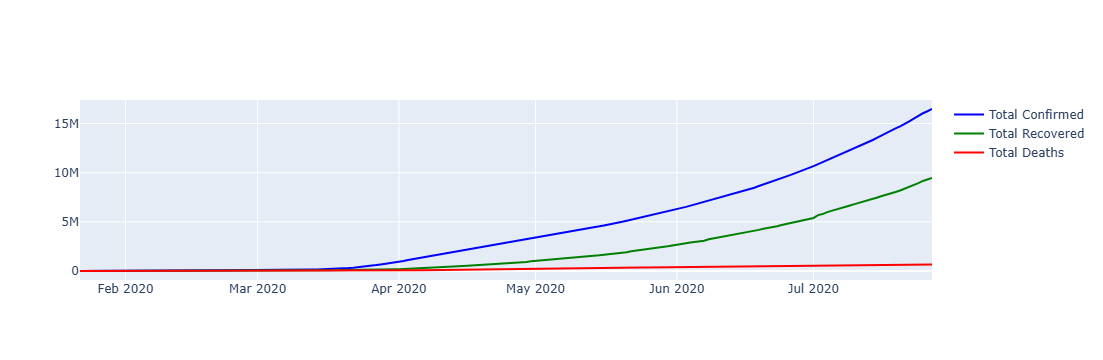

In [71]:
fig_trends = go.Figure()
fig_trends.add_trace(go.Scatter(
    x=summary_daily['date'], 
    y=summary_daily['confirmed'], 
    mode='lines', 
    name='Total Confirmed',
    line=dict(color='blue')
))
fig_trends.add_trace(go.Scatter(
    x=summary_daily['date'], 
    y=summary_daily['recovered'], 
    mode='lines', 
    name='Total Recovered',
    line=dict(color='green')
))
fig_trends.add_trace(go.Scatter(
    x=summary_daily['date'], 
    y=summary_daily['deaths'], 
    mode='lines', 
    name='Total Deaths',
    line=dict(color='red')
))



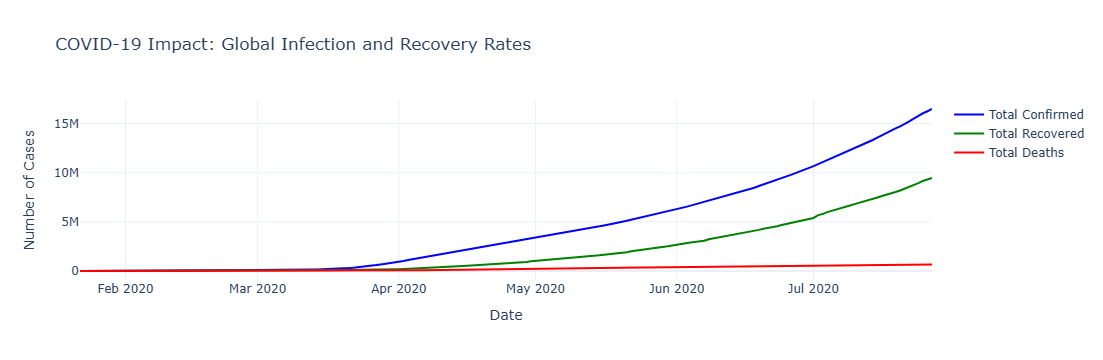

In [73]:
fig_trends.update_layout(
    title='COVID-19 Impact: Global Infection and Recovery Rates',
    xaxis_title='Date',
    yaxis_title='Number of Cases',
    hovermode='x unified', 
    template='plotly_white'
)
fig_trends.show()

Time Series Model using Prophet library

In [76]:
prophet_input = summary_daily[['date', 'confirmed']].copy()
prophet_input.columns = ['ds', 'y']


case_predictor = Prophet(yearly_seasonality=False, daily_seasonality=False)

case_predictor.fit(prophet_input)

future_dates = case_predictor.make_future_dataframe(periods=7)

forecast_data = case_predictor.predict(future_dates)

forecast_data[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

22:33:01 - cmdstanpy - INFO - Chain [1] start processing
22:33:01 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
185,2020-07-25,1.574174e+07,1.563204e+07,1.585106e+07
186,2020-07-26,1.593953e+07,1.582594e+07,1.603886e+07
187,2020-07-27,1.613441e+07,1.602847e+07,1.624382e+07
188,2020-07-28,1.632401e+07,1.621835e+07,1.643047e+07
189,2020-07-29,1.653405e+07,1.642929e+07,1.664735e+07
190,2020-07-30,1.674820e+07,1.664824e+07,1.685485e+07
191,2020-07-31,1.696362e+07,1.685354e+07,1.707130e+07
192,2020-08-01,1.717143e+07,1.706158e+07,1.727362e+07
193,2020-08-02,1.736922e+07,1.725490e+07,1.748180e+07
194,2020-08-03,1.756410e+07,1.744799e+07,1.767875e+07


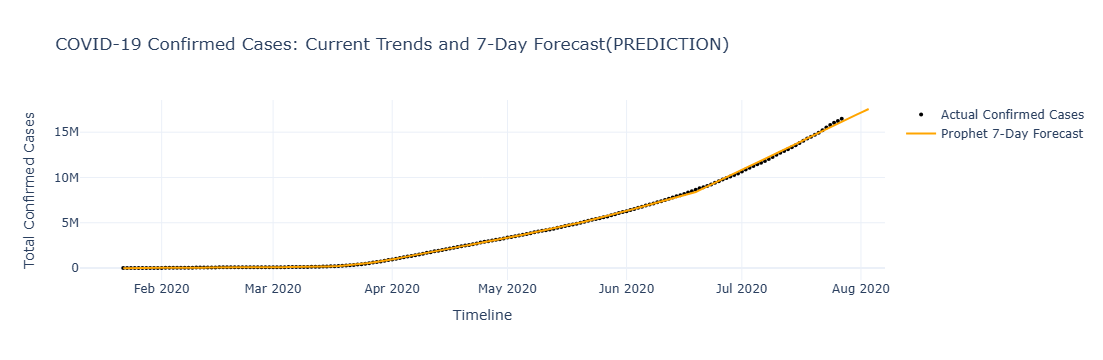

In [80]:
fig_forecast = go.Figure()

fig_forecast.add_trace(go.Scatter(
    x=prophet_input['ds'], 
    y=prophet_input['y'], 
    mode='markers', 
    name='Actual Confirmed Cases',
    marker=dict(color='black', size=4)
))

fig_forecast.add_trace(go.Scatter(
    x=forecast_data['ds'], 
    y=forecast_data['yhat'], 
    mode='lines', 
    name='Prophet 7-Day Forecast',
    line=dict(color='orange', width=2)
))

fig_forecast.update_layout(
    title='COVID-19 Confirmed Cases: Current Trends and 7-Day Forecast(PREDICTION)',
    xaxis_title='Timeline',
    yaxis_title='Total Confirmed Cases',
    hovermode='x unified',
    template='plotly_white'
)

fig_forecast.show()